In [1]:
import sys
import numpy as np
from scipy.stats import unitary_group
def num_to_bits(num, chunks):
    res, shp = np.repeat(num[np.newaxis,...], chunks, axis=0), [chunks] + [1] * len(num.shape)
    return ((res >> np.arange(0, 7 * chunks, 7).reshape(shp)) & np.array([((1 << 7)-1)]*(chunks-1)+[-1]).reshape(shp)).astype(np.int8)
def bits_to_num(num, offset=7):
    return np.sum(num.astype(np.int64) << np.arange(-offset, 7 * num.shape[1]-offset, 7), axis=1) #the high byte can be 0/-1 or this overflows...
def normalize_doubles(num, dimension, fractionbits=63):
    mantissas, exponents = np.frexp(num)
    maxexp = np.amax(exponents, axis=dimension)
    adjustmant = mantissas / (1 << ((maxexp[:,np.newaxis] if dimension==1 else maxexp) - exponents))
    return maxexp, np.rint(np.ldexp(adjustmant, fractionbits)).astype(np.int64) #(64, -62) bit fixed point integers
def renormalize_doubles(num, exp):
    return num.astype(np.float64) / (2 ** exp.astype(np.float64))
def vector_complex_to_real(cplx):
    dim = cplx.shape[1]//2 #len(cplx)//2
    return cplx[:,:dim] + cplx[:,dim:]*1j #return cplx[:dim] + cplx[dim:]*1j
def vector_real_to_complex(vec):
    return np.hstack((vec.real, vec.imag))
def matrix_real_to_complex(mtx):
    return np.vstack((np.hstack((mtx.real, -mtx.imag)), np.hstack((mtx.imag, mtx.real))))

In [2]:
import groq.api as g
import groq.api.instruction as inst
import groq.tensor as tensor
from groq.common import print_utils

def extract_int8(var):
    return g.concat_vectors([x.reinterpret(g.int8).split_vectors([1]*4)[0] for x in var], (len(var), var[0].shape[1]))
WEST, EAST = 0, 1
def get_slice4(drctn, start, end, bank=0):
    return "-1, H1(" + ("W" if drctn==WEST else "E") + "), S4(" + str(start) + "-" + str(end) + "), B1(" + str(bank) + ")"
def get_slice2(drctn, start, end, bank=0):
    return "-1, H1(" + ("W" if drctn==WEST else "E") + "), S2(" + str(start) + "-" + str(end) + "), B1(" + str(bank) + ")"
def get_slice1(drctn, start, bank=0):
    return "-1, H1(" + ("W" if drctn==WEST else "E") + "), S1(" + str(start) + "), B1(" + str(bank) + ")"
s16rangeW = list(range(25, 27+1))+list(range(29, 37+1))+list(range(39,42+1))
s16rangeE = list(range(26, 27+1))+list(range(29,42+1))
def get_slice16(drctn, slices, bank=0):
    return "-1, H1(" + ("W" if drctn==WEST else "E") + "), S16(" + ",".join(str(x) for x in slices) + "), B1(" + str(bank) + ")"

In [3]:
class VecMatMul(g.Component):
    def __init__(self, chunks, dim, **kwargs):
        super().__init__(**kwargs)
        self.chunks, self.dim = chunks, dim
        self.maskqrt, self.maskqrttop, self.shiftqrt, self.zeros = [], [], [], []
        for drctn in (WEST, EAST):
            self.maskqrt.append(g.concat_inner_splits(
                [g.from_data(np.array([[(1<<7)-1]*dim], dtype=np.int32), layout=get_slice4(drctn, 8, 11, drctn))] * chunks))
            self.maskqrttop.append(g.concat_inner_splits(
                [g.from_data(np.array([[(1<<7)-1]*dim], dtype=np.int32), layout=get_slice4(drctn, 32, 35, drctn))] * (chunks-1)+
                [g.from_data(np.array([[-1]*dim], dtype=np.int32), layout=get_slice4(drctn, 32, 35, drctn))]))
            self.shiftqrt.append(g.concat_inner_splits(
                [g.from_data(np.array([[7]*dim], dtype=np.int32), layout=get_slice4(drctn, 12, 15, drctn))] * chunks))
            self.shiftqrt.append(g.concat_inner_splits(
                [g.from_data(np.array([[7]*dim], dtype=np.int32), layout=get_slice4(drctn, 8, 11, drctn))] * chunks))
            g.add_mem_constraints(self.maskqrttop, self.maskqrttop, g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
            g.add_mem_constraints([self.shiftqrt[-1]], [self.maskqrt[-1]], g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
            #g.add_mem_constraints([maskqrt[-1], maskqrttop[-1], shiftqrt[-1]], [maskqrt[-1], maskqrttop[-1], shiftqrt[-1]], g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
            self.zeros.append(g.zeros(shape=(1,dim), dtype=g.int32, layout=get_slice4(drctn, 4, 7, 0)))
            self.zeros.append(g.zeros(shape=(1,dim), dtype=g.int32, layout=get_slice4(drctn, 4, 7, 1)))
            g.add_mem_constraints([self.zeros[-1]], [self.zeros[-2]], g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
        self.maskreqs = []
        self.splitreqs = []
        for drctn, plane in ((WEST, 0), (WEST, 1), (EAST, 0), (EAST, 1)):
            self.maskreqs.append([])
            self.splitreqs.append([])
            for i in range(chunks+1):            
                self.maskreqs[-1].append(tensor.create_storage_request(layout=get_slice4(drctn, 4, 7, plane)))
                self.splitreqs[-1].append(tensor.create_storage_request(layout=get_slice4(drctn, 0, 3, plane)))
    def build(self, tvec, tmat, inittime=0):
        # Instantiate matmul component.   
        # Build matmul component.
        g.add_mem_constraints(self.maskqrttop, tmat, g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
    
        final_result = []
        #split_result = []
        #allshifts = [zeros[0], zeros[1]]
        MATMULDELAY = 76 #4 (stream group size minus 1) for S16(25-27,29-37,39-42) to boundary, 9 for SXM crossing, 5 (stream group size) for weight install completion (not depended upon)
        #3 delay for S1(43) to allow weight install, 9 for SXM and 1 MXM weight crossing, #chunks for vector install (none of these are depended on)
        #weight install takes 3 ticks to start to finish on MXM basic
        #13 for MXM basic multiplication, 34 for SXM accumulation, 19 to stream across (6 leaving SXM, 10 stream crossings, 3 entering ALU)
        #4+9+3+13+34+19 - 6 = 76 #-6 because the S4(8-11)
        #mxm_rqs = [tensor.create_mxm_request(planes=[x], num_planes=1) for x in range(4)]
        #g.latch(maskqrt[1-drctn].read(streams=SG4_TO[3]), alu=3)
        for drctn, plane in ((WEST, 0), (WEST, 1), (EAST, 0), (EAST, 1)):
            if plane == 0:
                split_result = []
                allshifts = [self.zeros[drctn*2], self.zeros[drctn*2+1]]
            #mm = nn.MatMul(time=0, buffer_output=False, planes=mxm_rqs[drctn*2+plane].planes)
            result_mt = [g.concat_inner_splits(x) for x in zip(*(g.split_vectors(x, [self.dim]*self.chunks) for x in g.split_inner_splits(tmat[drctn*2+plane])))]
            #result_mt = g.split_vectors(tmat[drctn*2+plane], [self.dim]*self.chunks)
            SG4_FROM = g.SG4_E if drctn == WEST else g.SG4_W
            SG4_TO = g.SG4_W if drctn == WEST else g.SG4_E
            rev_last_alu = [4] if drctn == WEST else [7]
            rev_alu = [6] if drctn == WEST else [9]
            first_alu = [0] if drctn == WEST else [3]
            second_alu = [1] if drctn == WEST else [2]
            dirstr = ("W" if drctn == WEST else "E") + str(plane) + "P" + "_t" + str(inittime)
            t = inittime+plane*max(self.dim//16, 10)
            for i in range(self.chunks):
                with g.ResourceScope(name="matmul" + dirstr + str(i), is_buffered=True, time=t) as pred: #mm.end_time==20 #for plane 0 returns on SG4_E[4] #for nn.matmul time=plane*21+(20+12+9+1)*i due to SXM DIST
                    #result_mt[i] = mm.build(tvec[drctn*2+plane], result_mt[i])
                    #g.clear_mxm(planes=[plane], time=0)
                    mxm_rq = tensor.create_mxm_request(planes=[drctn*2+plane], num_planes=1)
                    iw = g.install_weights(result_mt[i], planes=mxm_rq, time=0) #.read(streams=g.SG16_W[plane] if drctn == WEST else g.SG16_E[plane]), time=0 if plane==0 else -18)
                    #iw = g.load_weight_buffer(result_mt[i], planes=mxm_rq, time=0)
                    #print(tvec[drctn*2+plane].shape, tvec[drctn*2+plane].physical_shape, result_mt[i].shape, result_mt[i].physical_shape)
                    result_mt[i] = tvec[drctn*2+plane].matmul(iw, planes=mxm_rq, num_planes=1, accum_input=None, time=0)
                    #result_mt[i] = tvec[drctn*2+plane].matmul(result_mt[i], planes=[plane], time=0)
                    split_result.append(g.concat_inner_splits(g.split_vectors(result_mt[i], [1]*self.chunks)))
                    #must be an arithmetic right shift (sign filled), not logical, but with signed types, this occurs
                    if i == 0:
                        nextmasks = g.bitwise_and(split_result[-1], self.maskqrt[drctn].read(streams=SG4_FROM[3]), alus=rev_last_alu, output_streams=SG4_TO[3]).write(name="mask" + dirstr + str(i), storage_req=self.maskreqs[drctn*2+plane][i])
                        split_result[-1] = split_result[-1].write(name="split" + dirstr + str(i), storage_req=self.splitreqs[drctn*2+plane][i])
                    else:
                        masks = g.concat_inner_splits(g.split_inner_splits(nextmasks)[1:] + [self.zeros[drctn*2+plane]]).read(streams=SG4_FROM[1])
                        shifts = g.right_shift(split_result[-2].read(streams=SG4_FROM[2 if drctn == WEST else 6]), self.shiftqrt[2*drctn].read(streams=SG4_FROM[0]), alus=[0] if drctn == WEST else [15], output_streams=SG4_FROM[2 if drctn == WEST else 6])
                        split_result[-1] = g.add(g.add(shifts, masks, alus=[1] if drctn == WEST else [14], output_streams=SG4_FROM[2 if drctn == WEST else 6]), split_result[-1], alus=rev_alu, output_streams=SG4_TO[2 if drctn == WEST else 6])
                        if i != self.chunks - 1:
                            nextmasks = g.bitwise_and(self.maskqrt[1-drctn].read(streams=SG4_TO[3 if drctn==WEST else 7]), split_result[-1], alus=[4] if drctn==WEST else [11], output_streams=SG4_TO[3 if drctn==WEST else 7]).write(name="mask" + dirstr + str(i), storage_req=self.maskreqs[drctn*2+plane][i])
                        else:
                            nextshifts = g.right_shift(split_result[-1], self.shiftqrt[2*(1-drctn)+1].read(streams=SG4_TO[3 if drctn==WEST else 7]), alus=[4] if drctn==WEST else [11], output_streams=SG4_TO[3 if drctn==WEST else 7]).write(name="shiftpre" + dirstr, storage_req=self.maskreqs[drctn*2+plane][i])
                        split_result[-1] = split_result[-1].write(name="split" + dirstr + str(i), storage_req=self.splitreqs[drctn*2+plane][i])
                        g.add_mem_constraints(split_result[:-1], [split_result[-1]], g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
                    allshifts.append(nextshifts if i == self.chunks-1 else nextmasks)
                    g.add_mem_constraints(allshifts[:-1], [allshifts[-1]], g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
                    t += max(self.dim//16*2, (27 if i==0 else 30))
            #with complex multiplication at dimension 80 and 64-bit, we surely need 2 of these rounds to converge
            with g.ResourceScope(name="finsma" + dirstr, is_buffered=True, time=t+MATMULDELAY-18): #+predecessors=[pred], time=None) as pred: #they are not all fitting in int8 yet but after first iteration, the final computation can occur
                cursplit = split_result[-1].read(streams=SG4_FROM[5])
                shifts = g.concat_inner_splits([self.zeros[drctn*2+plane]] + g.split_inner_splits(nextshifts)[:-1]).read(streams=SG4_FROM[3 if drctn==WEST else 7])
                masks = g.bitwise_and(cursplit, self.maskqrttop[drctn].read(streams=SG4_FROM[4], time=0), alus=rev_last_alu, output_streams=SG4_FROM[4])
                split_result.append(g.add(masks, shifts, alus=rev_alu, output_streams=SG4_TO[2 if drctn == WEST else 6]))
                #nextshifts = g.bitwise_and(split_result[-1], self.maskqrt[1-drctn].read(streams=SG4_TO[0]), alus=[0] if drctn == WEST else [15], output_streams=SG4_TO[3 if drctn==WEST else 7]).write(name="fixmask" + dirstr, storage_req=self.maskreqs[drctn*2+plane][self.chunks])
                nextshifts = g.right_shift(split_result[-1], self.shiftqrt[2*(1-drctn)+1].read(streams=SG4_TO[0]), alus=[0] if drctn == WEST else [15], output_streams=SG4_TO[3 if drctn==WEST else 7]).write(name="fixshift" + dirstr, storage_req=self.maskreqs[drctn*2+plane][self.chunks])
                split_result[-1] = split_result[-1].write(name="finsplit" + dirstr, storage_req=self.splitreqs[drctn*2+plane][self.chunks])
                g.add_mem_constraints(split_result[:-1], [split_result[-1]], g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
                allshifts.append(nextshifts) #allshifts.append(nextmasks)
                g.add_mem_constraints(allshifts[:-1], [allshifts[-1]], g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
                
            #chunks-1 correct 7-bit int8s
            #final adjustment for between 0-7 bit addition extra bits, for 64x64-127x127 this is exactly 7 bits
            with g.ResourceScope(name="fixsma" + dirstr, is_buffered=True, time=t+MATMULDELAY+9+10): #predecessors=[pred], time=None) as pred:
                cursplit = split_result[-1].read(streams=SG4_FROM[3])
                #masks = g.concat_inner_splits(g.split_inner_splits(nextmasks)[1:] + [self.zeros[drctn*2+plane]]).read(streams=SG4_FROM[0])
                #shifts = g.right_shift(cursplit, self.shiftqrt[2*drctn].read(streams=SG4_FROM[1], time=0), alus=first_alu, output_streams=SG4_FROM[1])
                masks = g.bitwise_and(cursplit, self.maskqrttop[drctn].read(streams=SG4_FROM[1], time=0), alus=first_alu, output_streams=SG4_FROM[1])
                shifts = g.concat_inner_splits([self.zeros[drctn*2+plane]] + g.split_inner_splits(nextshifts)[:-1]).read(streams=SG4_FROM[0])
                #split_result.append(g.add(shifts, masks, alus=second_alu, output_streams=SG4_TO[1]).write(name="fixsplit" + dirstr, layout=get_slice4(drctn, 0, 3, plane)))
                final_result.append(extract_int8(g.split_inner_splits(g.add(shifts, masks, alus=second_alu, output_streams=SG4_TO[1]))).write(name="extract" + dirstr, layout=get_slice1(drctn, 43, plane)))
                #final_result.append(g.add(shifts, masks, alus=second_alu, output_streams=SG4_TO[1]).write(name="extract" + dirstr, storage_req=self.splitreqs[drctn*2+plane][self.chunks]))
            #print("Cycle time: ", t+MATMULDELAY+9+10+31+19) #31 through ALU, 19 to write to S43
        g.add_mem_constraints(tvec + final_result, final_result, g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
        return final_result, t+MATMULDELAY+9+10+31+19
class LoopCorrections(g.Component):
    def __init__(self, chunks, dim, matpow, **kwargs):
        super().__init__(**kwargs)
        self.chunks, self.dim, self.matpow = chunks, dim, (dim//2-1) if matpow is None else matpow
    def build(self, tmat, diag, cx_diag):
        results_mt = [diag]
        VMM = VecMatMul(self.chunks, self.dim)
        pred = None
        diag_mt = diag
        for i in range(self.matpow):
            with g.ResourceScope(name="vecmatmul", is_buffered=True, time=0 if pred is None else None, predecessors=None if pred is None else [pred]) as pred:
                diag_mt, t = VMM.build(diag_mt, tmat)
                results_mt.append(diag_mt)
        flat = [y for x in results_mt for y in x]
        g.add_mem_constraints(flat, flat, g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
        #with g.ResourceScope(name="vecmatfin", is_buffered=True, time=None, predecessors=[pred]) as pred:
        #    finresult_mt = VecMatMul(self.chunks, self.dim).build(cx_diag, results_mt)
        #with g.ResourceScope(name="advgraycode", is_buffered=True, time=None, predecessors=[pred]) as pred:
        #    tmat, cx_diag = AdvanceGrayCode(self.chunks, self.dim).build(cx_diag, tmat)
        return results_mt[-1]

In [9]:
def vecMulDemo():
    import timeit
    dim = 80 #dim X dim complex matrix
    bitsize = 64 #for fixed point representation will round up to nearest multiple of 7
    chunks = (bitsize + 7-1)//7 #ceiling division to be exact
    matpow = 1 #dim//2-1
    tvec, tmat = [], []
    for group in (0,):
        for drctn, plane in ((WEST, 0), (WEST, 1), (EAST, 0), (EAST, 1)):
            dirstr = ("W" if drctn == WEST else "E") + str(plane) + "P"
            tvec.append(g.input_tensor(shape=(chunks, dim*2*2), dtype=g.int8, name="A" + dirstr + str(group), layout=get_slice1(drctn, 43, plane)))
            tmat.append(g.input_tensor(shape=(chunks*dim*2*2, dim*2*2), dtype=g.int8, name="B" + dirstr + str(group), layout=get_slice16(drctn, s16rangeW if drctn == WEST else s16rangeE, plane))) 
    g.add_mem_constraints(tvec, tvec, g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)
    g.add_mem_constraints(tmat, tmat, g.MemConstraintType.NOT_MUTUALLY_EXCLUSIVE)

    parallel = len(tvec)*2
    result_mt = LoopCorrections(chunks, dim*2*2, matpow).build(tmat, tvec, None)

    print_utils.infoc("\nCompiling model ...")
    # Compile program to generate IOP. Also generate groqview JSON dump file and
    # check for potential stream conflicts.
    iop_file = g.compile(
        base_name="mm_fp", gen_vis_data=False, check_stream_conflicts=False, result_tensor=result_mt, #tree_conflicts=True, inspect_raw=True
    )
    json_file = g.write_visualizer_data("mm_fp")
    print_utils.cprint("Have a GroqView:\n    % " + print_utils.Colors.GREEN + "groqview --port 8888 " + json_file + print_utils.Colors.RESET, "")
    #g.check_stream_conflicts(json_file)    

    originpvec = [np.random.rand(dim)*2-1 + (np.random.rand(dim)*2j-1j) for _ in range(parallel)]
    originpmat = [unitary_group.rvs(dim) for _ in range(parallel)]

    oracleres = [None]
    def oracle():
        B = [originpmat[i].transpose().astype(np.clongdouble) for i in range(parallel)]
        oracleres[0] = []
        for i in range(parallel):
            w = originpvec[i].astype(np.clongdouble)
            for _ in range(matpow):
                w = w @ B[i]
            oracleres[0].append(w.astype(np.cdouble))
    toracle = timeit.timeit(oracle, number=10)/10
    print_utils.infoc("\nRunning on HW ...")
    np.set_printoptions(formatter={'int':hex}, threshold=sys.maxsize, floatmode='unique')
    # Create TSP runner and pass input dictionary of "tensor name" : "tensor data".
    runner = g.create_tsp_runner(iop_file)
    results = [None]
    def actual():
        fractionbits = 63
        inputs = {}
        exp_inpvecs, exp_inpmats, Z = [], [], np.zeros((chunks, dim*2, dim*2), dtype=np.int8)
        for i in range(parallel//2):
            exp_inpvec0, normals = normalize_doubles(vector_real_to_complex(originpvec[i*2]), 0, fractionbits)
            inpvec0 = num_to_bits(normals, chunks)
            exp_inpmat0, normals = normalize_doubles(matrix_real_to_complex(originpmat[i*2]), None, fractionbits) #dimension 1 will cause chaining issues without shift corrections
            inpmat0 = num_to_bits(normals, chunks).reshape((chunks, dim*2, dim*2))
            exp_inpvec1, normals = normalize_doubles(vector_real_to_complex(originpvec[i*2+1]), 0, fractionbits)
            inpvec1 = num_to_bits(normals, chunks)
            exp_inpmat1, normals = normalize_doubles(matrix_real_to_complex(originpmat[i*2+1]), None, fractionbits) #dimension 1 will cause chaining issues without shift corrections
            inpmat1 = num_to_bits(normals, chunks).reshape((chunks, dim*2, dim*2))
            inputs[tvec[i].name] = np.hstack((inpvec0, inpvec1))            
            inputs[tmat[i].name] = np.concatenate((np.concatenate((inpmat0, Z), axis=2), np.concatenate((Z, inpmat1), axis=2)), axis=1).reshape((chunks*dim*2*2, dim*2*2))
            exp_inpvecs.extend([exp_inpvec0, exp_inpvec1]); exp_inpmats.extend([exp_inpmat0, exp_inpmat1])
        res = runner(**inputs)
        results[0] = []
        for i in range(parallel//2):
            result = bits_to_num(res[result_mt[i].name].reshape(chunks, dim*2*2).transpose(), 7)
            #the results come back truncating the lower 7*(chunks-1) bits
            results[0].append(vector_complex_to_real(renormalize_doubles(result[:dim*2], fractionbits - 7 - exp_inpvecs[i*2] - exp_inpmats[i*2]*matpow).reshape(1, dim*2)).reshape(dim))
            results[0].append(vector_complex_to_real(renormalize_doubles(result[dim*2:], fractionbits - 7 - exp_inpvecs[i*2+1] - exp_inpmats[i*2+1]*matpow).reshape(1, dim*2)).reshape(dim))
    tactual = timeit.timeit(actual, number=1)/1
    g.reset_program_context()
    print("CPU Time", toracle, "Groq Time", tactual)
    oracleres, results = oracleres[0], results[0]
    for i in range(parallel):
        print_utils.infoc("\nComparing results with oracle ...")
        max_atol = max(abs(oracleres[i].reshape(-1) - results[i].reshape(-1)))
        if max_atol <= 0.001:
            print_utils.success(f"Test PASSED with a max tolerance of {max_atol}")
        else:
            print_utils.err(
                f"Test FAILED with a max tolerance of {max_atol} (should be <= 0.001)"
            )

In [8]:
vecMulDemo()


Compiling model ...

Have a GroqView:
    % groqview mm_fp.json
    (groqview is found in /usr/local/groq/bin)

To specify a different port, add this:
    --port <PORT>

Have a GroqView:
    % groqview --port 8888 mm_fp.json

Running on HW ...
CPU Time 0.0006497299298644065 Groq Time 0.017962041776627302

Comparing results with oracle ...
Test PASSED with a max tolerance of 1.2412670766236366e-16

Comparing results with oracle ...
Test PASSED with a max tolerance of 1.1102230246251565e-16

Comparing results with oracle ...
Test PASSED with a max tolerance of 1.1102230246251565e-16

Comparing results with oracle ...
Test PASSED with a max tolerance of 1.1102230246251565e-16

Comparing results with oracle ...
Test PASSED with a max tolerance of 2.220446049250313e-16

Comparing results with oracle ...
Test PASSED with a max tolerance of 1.1443916996305594e-16

Comparing results with oracle ...
Test PASSED with a max tolerance of 1.1102230246251565e-16

Comparing results with oracle ...
T

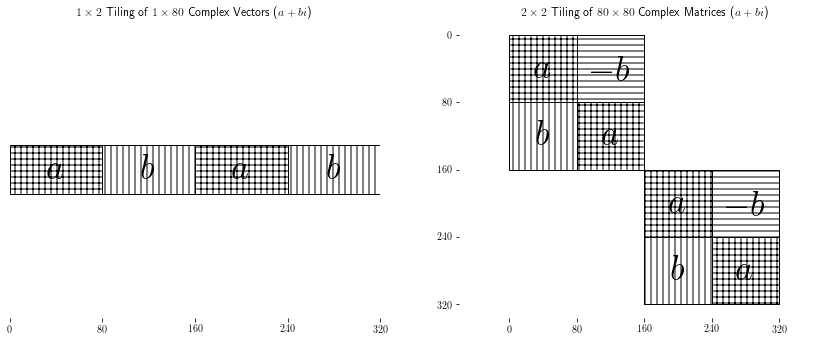

In [146]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['pgf.texsystem'] = 'pdflatex'
from matplotlib.patches import Rectangle
fig, axs = plt.subplots(1, 2)
fig.tight_layout()
fig.set_figheight(4.8)
fig.set_figwidth(6.4*2)
ax = axs[0]
ax.set_xticks(range(0, 320+1, 80))
ax.set_xlim(0, 320)
ax.set_ylim(2.5+1, 0-2.5)
ax.get_yaxis().set_visible(False)
for x in ax.spines: ax.spines[x].set_visible(False)
quads=(((0,0), "a"), ((80, 0), "b"))
for quad in quads:
    ax.add_patch(Rectangle(quad[0], 80, 1, fill=False,
                            hatch='++' if quad[1]=='a' else '--' if quad[1] == '-b' else '||'))
    ax.text(quad[0][0]+40, quad[0][1]+0.5, '$' + quad[1] + '$', size=35, ha="center", va="center")
    ax.add_patch(Rectangle((quad[0][0]+160, quad[0][1]), 80, 1, fill=False,
                           hatch='++' if quad[1]=='a' else '--' if quad[1] == '-b' else '||'))
    ax.text(quad[0][0]+160+40, quad[0][1]+0.5, '$' + quad[1] + '$', size=35, ha="center", va="center")
ax.set_title("$1\\times 2$ Tiling of $1\\times 80$ Complex Vectors ($a+bi$)")
ax = axs[1]
ax.set_xticks(range(0, 320+1, 80))
ax.set_yticks(range(0, 320+1, 80))
ax.set_xlim(0, 320)
ax.set_ylim(320, 0)
ax.axis('equal')
for x in ax.spines: ax.spines[x].set_visible(False)
quads=(((0,0), "a"), ((80,0), "-b"), ((0,80), "b"), ((80,80), "a"))
for quad in quads:
    ax.add_patch(Rectangle(quad[0], 80, 80, fill=False,
                            hatch='++' if quad[1]=='a' else '--' if quad[1] == '-b' else '||'))
    ax.text(quad[0][0]+40, quad[0][1]+40, '$' + quad[1] + '$', size=35, ha="center", va="center")
    ax.add_patch(Rectangle((quad[0][0]+160, quad[0][1]+160), 80, 80, fill=False,
                           hatch='++' if quad[1]=='a' else '--' if quad[1] == '-b' else '||'))
    ax.text(quad[0][0]+160+40, quad[0][1]+160+40, '$' + quad[1] + '$', size=35, ha="center", va="center")
ax.set_title("$2\\times 2$ Tiling of $80\\times 80$ Complex Matrices ($a+bi$)")
fig.savefig("tiling.svg")
fig.show()

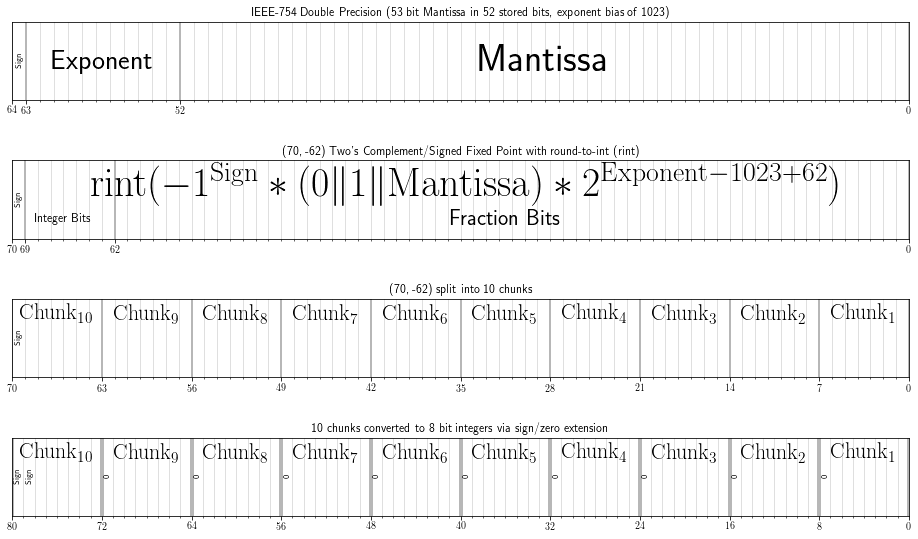

In [132]:
fig, axs = plt.subplots(4, 1)
fig.tight_layout()
fig.set_figheight(4*2)
fig.set_figwidth(14)
ax = axs[0]
ax.set_xlim(64, 0)
ax.set_ylim(0, 1)
ax.set_xticks([0, 52, 63, 64])
ax.set_xticks(range(64+1), minor=True)
ax.get_yaxis().set_visible(False)
ax.grid(which='minor', alpha=0.5)
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.text(63.5, 0.5, "Sign", size=8, ha="center", va="center", rotation=90)
ax.text(52+(63-52)/2, 0.5, "Exponent", size=28, ha="center", va="center")
ax.text(52/2, 0.5, "Mantissa", size=38, ha="center", va="center")
ax.set_title("IEEE-754 Double Precision (53 bit Mantissa in 52 stored bits, exponent bias of 1023)")
ax = axs[1]
ax.set_xlim(70, 0)
ax.set_xticks([0, 62, 69, 70])
ax.set_xticks(range(70+1), minor=True)
ax.get_yaxis().set_visible(False)
ax.grid(which='minor', alpha=0.5)
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.text(69.5, 0.5, "Sign", size=8, ha="center", va="center", rotation=90)
ax.text(34.5, 0.7, "$\mathrm{rint}(-1^{\mathrm{Sign}}*(0 \\Vert 1 \\Vert \mathrm{Mantissa}) * 2^{\mathrm{Exponent}-1023+62})$", size=40, ha="center", va="center")
ax.text(66, 0.25, "Integer Bits", size=12, ha="center", va="center")
ax.text(63/2, 0.25, "Fraction Bits", size=22, ha="center", va="center")
ax.set_title("(70, -62) Two's Complement/Signed Fixed Point with round-to-int (rint)")
ax = axs[2]
ax.set_xlim(70, 0)
ax.set_xticks(range(0, 70+1, 7))
ax.set_xticks(range(70+1), minor=True)
ax.get_yaxis().set_visible(False)
ax.grid(which='minor', alpha=0.5)
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.text(69.5, 0.5, "Sign", size=8, ha="center", va="center", rotation=90)
for i in range(10):
    ax.text(7*i+3.5, 0.75, "$\mathrm{Chunk}_{"+f"{i+1}" + "}$", size=22, ha="center", va="center")
ax.set_title("(70, -62) split into 10 chunks")
ax = axs[3]
ax.set_xlim(80, 0)
ax.set_xticks(range(0, 80+1, 8))
ax.set_xticks(range(80+1), minor=True)
ax.get_yaxis().set_visible(False)
ax.grid(which='minor', alpha=0.5)
ax.grid(which='major', alpha=0.9, linewidth=4)
ax.text(78.5, 0.5, "Sign", size=8, ha="center", va="center", rotation=90)
for i in range(10):
    ax.text(8*i+7.5, 0.5, "Sign" if i==9 else "0", size=8, ha="center", va="center", rotation=90)
    ax.text(8*i+4, 0.75, "$\mathrm{Chunk}_{"+f"{i+1}" + "}$", size=22, ha="center", va="center")
ax.set_title("10 chunks converted to 8 bit integers via sign/zero extension")
fig.savefig("floattochunkedfix.svg")
fig.show()

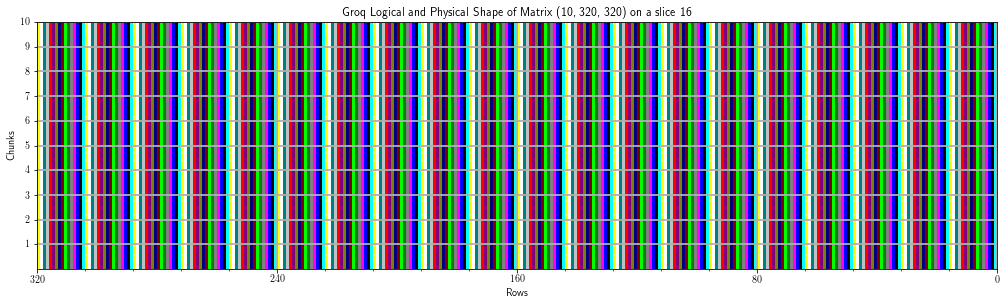

In [133]:
fig, axs = plt.subplots(1, 1)
fig.set_figwidth(14)
fig.tight_layout()
ax = axs
ax.set_xlim(320, 0)
ax.set_ylim(0, 10)
ax.set_xticks(range(0, 320+1, 80))
ax.set_xticks(range(0, 320+1, 16), minor=True)
ax.set_yticks(range(1, 10+1))
ax.set_ylabel("Chunks")
ax.set_xlabel("Rows")
import matplotlib.colors as mcolors
html16 = ["aqua", "black", "blue", "fuchsia", "gray", "green", "lime", "maroon", "navy", "olive", "purple", "red", "silver", "teal", "white", "yellow"]
ax.bar([0.5+x for x in range(320)], [10]*320, width=1, color=[mcolors.CSS4_COLORS[x] for x in html16])
#ax.get_yaxis().set_visible(False)
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Groq Logical and Physical Shape of Matrix (10, 320, 320) on a slice 16")
fig.savefig("groqmatrix.svg")
fig.show()

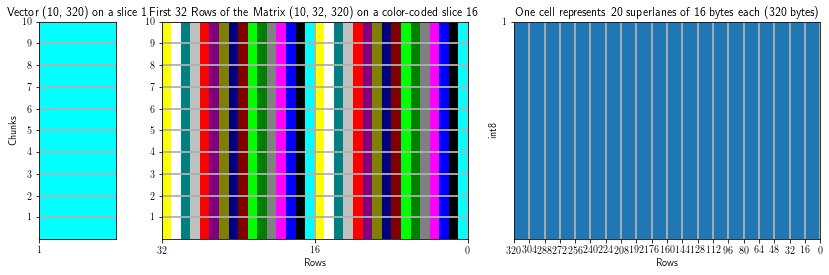

In [148]:
fig, axs = plt.subplots(1, 3, gridspec_kw={'width_ratios': [1, 4, 4]})
fig.set_figwidth(14)
ax = axs[0]
ax.set_xlim(1, 0)
ax.set_ylim(0, 10)
ax.set_xticks(range(1, 1+1))
ax.set_yticks(range(1, 10+1))
ax.set_ylabel("Chunks")
ax.bar(0.5, [10], width=1, color=[mcolors.CSS4_COLORS[html16[0]]])
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Vector (10, 320) on a slice 1")
ax = axs[1]
ax.set_xlim(32, 0)
ax.set_ylim(0, 10)
ax.set_xticks(range(0, 32+1, 16))
ax.set_yticks(range(1, 10+1))
ax.set_xlabel("Rows")
ax.bar([0.5+x for x in range(32)], [10]*32, width=1, color=[mcolors.CSS4_COLORS[x] for x in html16])
#ax.get_yaxis().set_visible(False)
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("First 32 Rows of the Matrix (10, 32, 320) on a color-coded slice 16")
ax = axs[2]
ax.set_xlim(320, 0)
ax.set_ylim(0, 1)
ax.set_xticks(range(0, 320+1, 16))
ax.set_yticks(range(1, 1+1))
ax.set_ylabel("int8")
ax.set_xlabel("Rows")
ax.bar([8.5+x for x in range(0, 320, 16)], [1]*20, width=16)
#ax.get_yaxis().set_visible(False)
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("One cell represents 20 superlanes of 16 bytes each (320 bytes)")
fig.savefig("groqvectorslicesuperlane.svg")
fig.show()

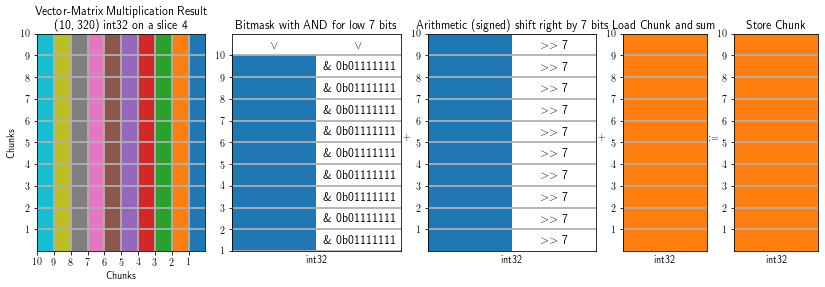

In [149]:
fig, axs = plt.subplots(1, 5, gridspec_kw={'width_ratios': [2, 2, 2, 1, 1]})
fig.set_figwidth(14)
#fig.tight_layout()
ax = axs[0]
ax.set_xlim(10, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(range(1, 10+1))
ax.set_ylabel("Chunks")
ax.set_xlabel("Chunks")
ax.bar([0.5+x for x in range(10)], [10]*10, width=1, color=mcolors.TABLEAU_COLORS)
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Vector-Matrix Multiplication Result\n (10, 320) int32 on a slice 4")
ax = axs[1]
ax.set_xlim(2, 0)
ax.set_ylim(1, 11)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_xlabel("int32")
ax.bar(1.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[0])
ax.grid(which='major', alpha=0.9, linewidth=2)
for i in range(9):
    ax.text(0.5, 1.5+i, "\\& 0b" + "0"+"1"*7, size=12, ha="center", va="center")
ax.text(0.5, 1.5+9, "$>$", size=12, ha="center", va="center", rotation=270)
ax.text(1.5, 1.5+9, "$>$", size=12, ha="center", va="center", rotation=270)
ax.set_title("Bitmask with AND for low 7 bits")
ax = axs[2]
ax.set_xlim(2, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel("+", rotation=0)
ax.set_xlabel("int32")
ax.bar(1.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[0])
ax.grid(which='major', alpha=0.9, linewidth=2)
for i in range(10):
    ax.text(0.5, 0.5+i, "$>>$ 7", size=12, ha="center", va="center")
ax.set_title("Arithmetic (signed) shift right by 7 bits")
ax = axs[3]
ax.set_xlim(1, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel("+", rotation=0)
ax.set_xlabel("int32")
ax.bar(0.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[1])
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Load Chunk and sum")
ax = axs[4]
ax.set_xlim(1, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel(":=", rotation=0)
ax.set_xlabel("int32")
ax.bar(0.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[1])
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Store Chunk")
fig.savefig("groqmulfirststep.svg")
fig.show()

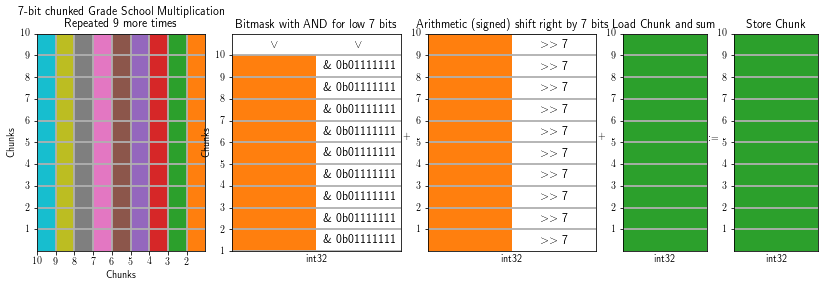

In [150]:
fig, axs = plt.subplots(1, 5, gridspec_kw={'width_ratios': [2, 2, 2, 1, 1]})
fig.set_figwidth(14)
ax = axs[0]
ax.set_xlim(10, 1)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(range(1+1, 10+1))
ax.set_ylabel("Chunks")
ax.set_xlabel("Chunks")
ax.bar([1.5+x for x in range(9)], [10]*9, width=1, color=list(mcolors.TABLEAU_COLORS)[1:])
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("7-bit chunked Grade School Multiplication\nRepeated 9 more times")
ax = axs[1]
ax.set_xlim(2, 0)
ax.set_ylim(1, 11)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel("Chunks")
ax.set_xlabel("int32")
ax.bar(1.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[1])
ax.grid(which='major', alpha=0.9, linewidth=2)
for i in range(9):
    ax.text(0.5, 1.5+i, "\\& 0b" + "0"+"1"*7, size=12, ha="center", va="center")
ax.text(0.5, 1.5+9, "$>$", size=12, ha="center", va="center", rotation=270)
ax.text(1.5, 1.5+9, "$>$", size=12, ha="center", va="center", rotation=270)
ax.set_title("Bitmask with AND for low 7 bits")
ax = axs[2]
ax.set_xlim(2, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel("+", rotation=0)
ax.set_xlabel("int32")
ax.bar(1.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[1])
ax.grid(which='major', alpha=0.9, linewidth=2)
for i in range(10):
    ax.text(0.5, 0.5+i, "$>>$ 7", size=12, ha="center", va="center")
ax.set_title("Arithmetic (signed) shift right by 7 bits")
ax = axs[3]
ax.set_xlim(1, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel("+", rotation=0)
ax.set_xlabel("int32")
ax.bar(0.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[2])
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Load Chunk and sum")
ax = axs[4]
ax.set_xlim(1, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel(":=", rotation=0)
ax.set_xlabel("int32")
ax.bar(0.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[2])
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Store Chunk")
fig.savefig("groqmulgradeschool.svg")
fig.show()

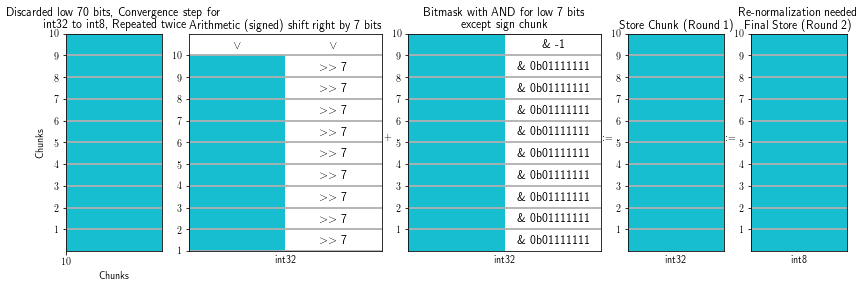

In [152]:
fig, axs = plt.subplots(1, 5, gridspec_kw={'width_ratios': [1, 2, 2, 1, 1]})
fig.set_figwidth(14)
ax = axs[0]
ax.set_xlim(10, 9)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(range(1+9, 10+1))
ax.set_ylabel("Chunks")
ax.set_xlabel("Chunks")
ax.bar([9.5+x for x in range(1)], [10]*1, width=1, color=list(mcolors.TABLEAU_COLORS)[-1])
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Discarded low 70 bits, Convergence step for\nint32 to int8, Repeated twice")
ax = axs[1]
ax.set_xlim(2, 0)
ax.set_ylim(1, 11)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_xlabel("int32")
ax.bar(1.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[-1])
ax.grid(which='major', alpha=0.9, linewidth=2)
for i in range(9):
    ax.text(0.5, 1.5+i, "$>>$ 7" , size=12, ha="center", va="center")
ax.text(0.5, 1.5+9, "$>$", size=12, ha="center", va="center", rotation=270)
ax.text(1.5, 1.5+9, "$>$", size=12, ha="center", va="center", rotation=270)
ax.set_title("Arithmetic (signed) shift right by 7 bits")
ax = axs[2]
ax.set_xlim(2, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel("+", rotation=0)
ax.set_xlabel("int32")
ax.bar(1.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[-1])
ax.grid(which='major', alpha=0.9, linewidth=2)
for i in range(10):
    ax.text(0.5, 0.5+i, "\\& -1" if i==9 else "\\& 0b" + "0"+"1"*7, size=12, ha="center", va="center")
ax.set_title("Bitmask with AND for low 7 bits\nexcept sign chunk")
ax = axs[3]
ax.set_xlim(1, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel(":=", rotation=0)
ax.set_xlabel("int32")
ax.bar(0.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[-1])
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Store Chunk (Round 1)")
ax = axs[4]
ax.set_xlim(1, 0)
ax.set_ylim(0, 10)
ax.set_yticks(range(1, 10+1))
ax.set_xticks(())
ax.set_ylabel(":=", rotation=0)
ax.set_xlabel("int8")
ax.bar(0.5, [10], width=1, color=list(mcolors.TABLEAU_COLORS)[-1])
ax.grid(which='major', alpha=0.9, linewidth=2)
ax.set_title("Re-normalization needed\nFinal Store (Round 2)")
fig.savefig("groqmulconvergence.svg")
fig.show()